In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt

In [90]:
df=pd.read_csv("height-weight.csv")

In [91]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


<Axes: xlabel='Height'>

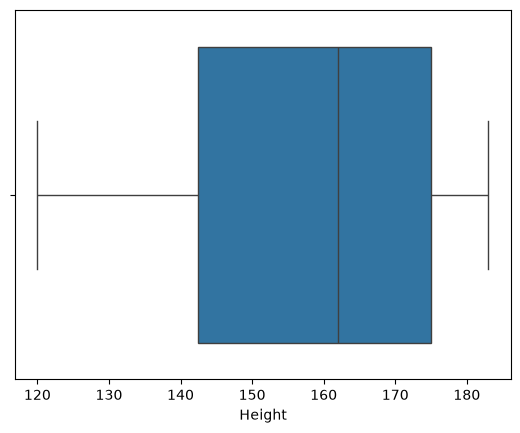

In [93]:
sns.boxplot(x="Height",data=df)

<Axes: xlabel='Height', ylabel='Weight'>

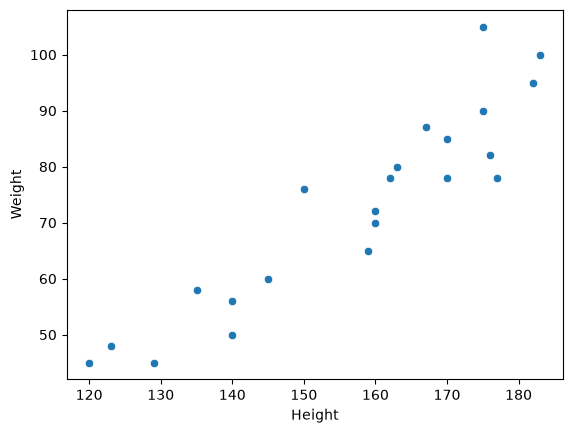

In [94]:
sns.scatterplot(x="Height",y="Weight",data=df)

In [95]:
df[df["Height"].isnull()].sum()

Weight    0
Height    0
dtype: int64

<Axes: xlabel='Weight'>

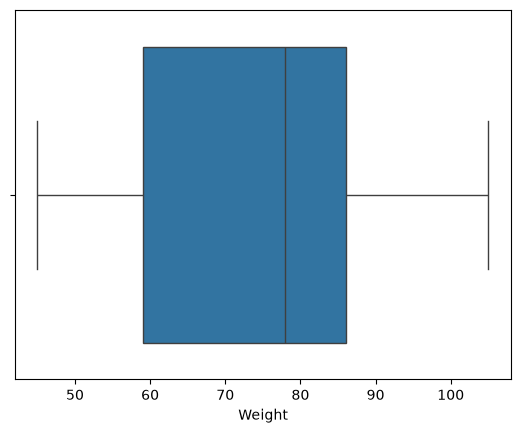

In [96]:
sns.boxplot(x="Weight",data=df)

In [97]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [98]:
df[df.isnull()].sum()

Weight    0.0
Height    0.0
dtype: float64

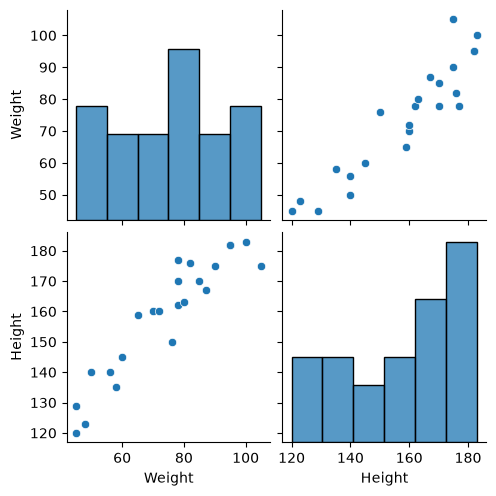

In [99]:
sns.pairplot(data=df)

In [100]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [101]:
X=df[["Weight"]]#independent feature use [[]] otherwise it will get converted to series
type(X)#2D-array
X.shape

(23, 1)

In [102]:
X1=df["Weight"]
X2=np.array(X1)
X2.shape

(23,)

In [103]:
Y=df[["Height"]]

In [104]:
df["Height"].describe()

count     23.000000
mean     158.391304
std       19.511626
min      120.000000
25%      142.500000
50%      162.000000
75%      175.000000
max      183.000000
Name: Height, dtype: float64

In [105]:
df["Weight"].describe()

count     23.000000
mean      73.826087
std       17.872407
min       45.000000
25%       59.000000
50%       78.000000
75%       86.000000
max      105.000000
Name: Weight, dtype: float64

In [106]:
from sklearn.model_selection import train_test_split

In [107]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=42)

In [108]:
X_train

,Weight
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50
21,56


In [109]:
#Standardization(Mean=0 & SD=1)
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train=scale.fit_transform(X_train)

In [110]:
X_test=scale.transform(X_test)

In [111]:
#LinearRegression
from sklearn.linear_model import LinearRegression as LR

In [112]:
Regression=LR(n_jobs=-1)
Regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
Regression.coef_

array([[17.03207732]])

In [114]:
Regression.intercept_

array([157.8125])

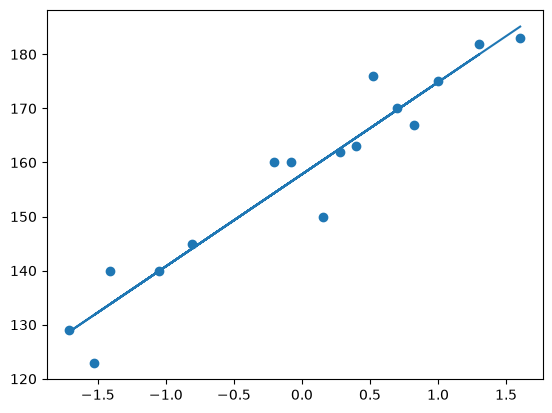

In [115]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,Regression.predict(X_train))

In [116]:
y_pred=Regression.predict(X_test)

Performance Metrics

In [117]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [118]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

103.09818711844574
9.237776679921925
10.153727744944009


In [119]:
from sklearn.metrics import r2_score

In [120]:
acc=r2_score(Y_test,y_pred)
acc

0.7828485570493535

OLS Method

In [121]:
import statsmodels.api as sm

In [122]:
model=sm.OLS(Y_train,X_train).fit()

In [123]:
model.predict(X_test)

array([  4.74495791,   4.74495791, -29.11095796,  22.18588426,
        -8.59222107,  32.44525271, -15.77377898])

In [124]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.054
Method:                 Least Squares   F-statistic:                             0.1745
Date:                Wed, 01 Jul 2026   Prob (F-statistic):                       0.682
Time:                        13:54:30   Log-Likelihood:                         -103.69
No. Observations:                  16   AIC:                                      209.4
Df Residuals:                      15   BIC:                                      210.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.0321     40.767      0.418      0.682     -69.861     103.925
==============================================================================
Omnibus:                        0.957   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.620   Jarque-Bera (JB):                0.320
Skew:                          -0.347   Prob(JB):                        0.852
Kurtosis:                       2.998   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""